In [1]:
#!pip install jax matplotlib scipy numpy

GRAPE Optimization Tutorial: Transmon Qubit (Closed System)
System: 4-level transmon
Anharmonicity: -200.0 MHz
Gate time: 15.0 ns
Time resolution: 1.0 ns
Initial Rabi frequency: 50.0 MHz
Initial fidelity: 0.496445

Starting GRAPE optimization...
(This may take 30-60 seconds)

Iter 0: Fidelity = 0.496445, φ = 0.0000, |∇| = 1.92e-01
Iter 10: Fidelity = 0.497115, φ = -0.0089, |∇| = 1.92e-01

Optimization Results
Final fidelity:     0.999991
Infidelity:         9.46e-06
Optimized phase φ:  91.7224 rad (5255.30°)
Iterations:         5
Converged:          True

Generating plots...


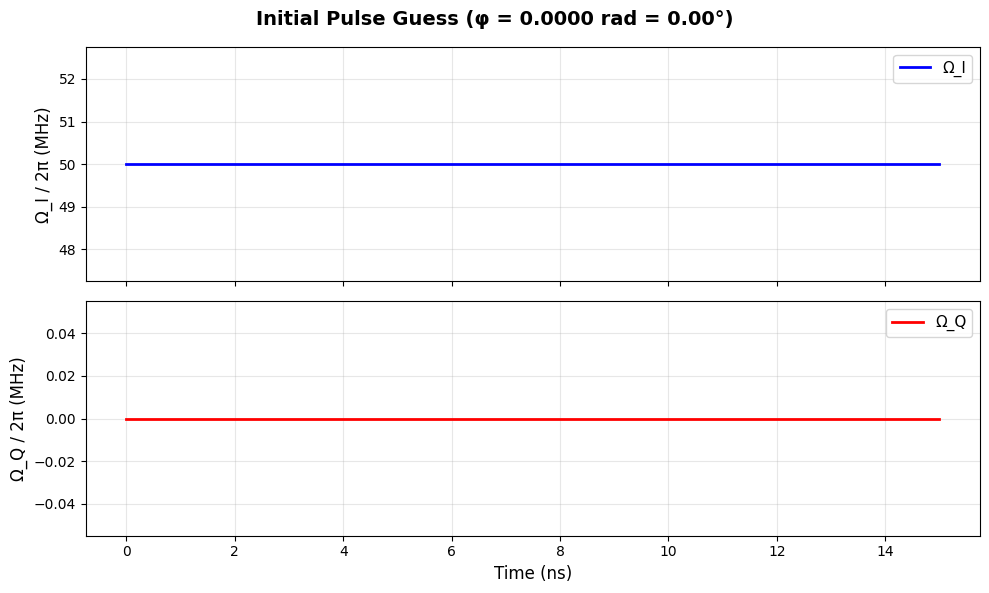

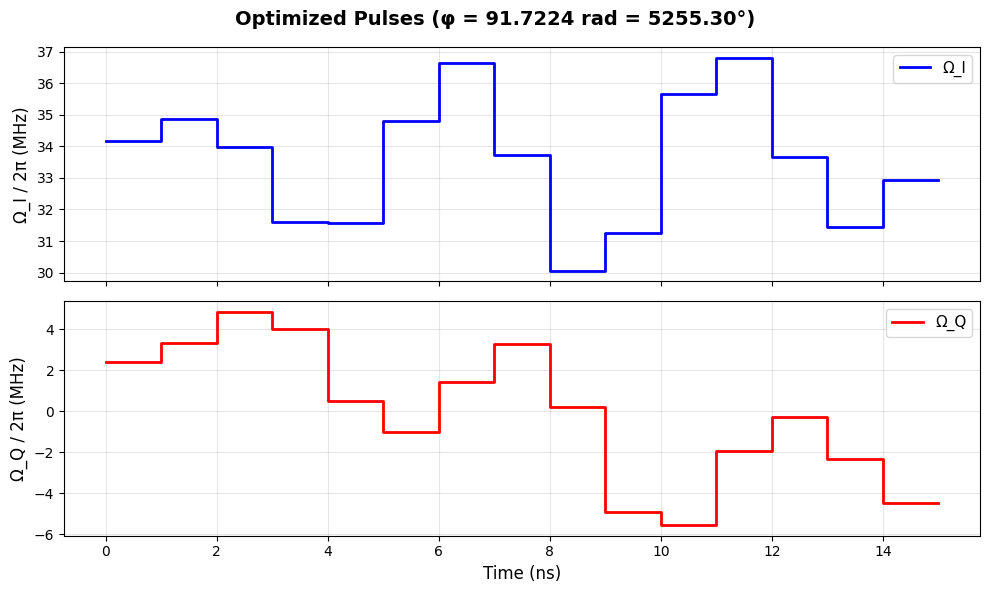


Final State Analysis:
----------------------------------------
  |0⟩: 0.000000
  |1⟩: 0.999991
  |2⟩: 0.000000
  |3⟩: 0.000009

Leakage to |2⟩ and above: 0.000009

Tutorial completed successfully!

Next steps:
  • Try different gate times (n_steps)
  • Experiment with detuning (omega_d ≠ omega_q)
  • Add pulse amplitude constraints
  • Optimize for other gates (X, Y, √X, etc.)


In [2]:
import jax
import jax.numpy as jnp
from jax import grad, jit
from scipy.optimize import minimize
import numpy as np
from functools import partial
import matplotlib.pyplot as plt

# Enable 64-bit precision for numerical accuracy
jax.config.update("jax_enable_x64", True)

class TransmonGRAPE:
    """
    GRAPE (Gradient Ascent Pulse Engineering) optimization for transmon qubit 
    in the rotating frame.
    
    This class implements pulse optimization for a multilevel transmon system
    using autodifferentiation through JAX for efficient gradient computation.
    """
    def __init__(self, n_levels, alpha, omega_d, omega_q, dt, n_steps):
        """
        Initialize the GRAPE optimizer for a transmon qubit.
        
        Parameters:
        -----------
        n_levels : int
            Number of transmon energy levels to include in simulation.
            Typical values: 3-5 (including ground state).
        alpha : float
            Anharmonicity in angular frequency units (rad/s).
            For transmons, typically negative: α ≈ -2π × (200 MHz).
        omega_d : float
            Drive frequency in rad/s.
        omega_q : float
            Qubit transition frequency (|0⟩ to |1⟩) in rad/s.
        dt : float
            Time step for pulse discretization in seconds.
            Should be much smaller than 1/Ω_Rabi for accuracy.
        n_steps : int
            Number of discrete time steps in the pulse sequence.
        """
        self.n_levels = n_levels
        self.alpha = alpha
        self.omega_d = omega_d
        self.omega_q = omega_q
        self.delta = omega_d - omega_q  # Detuning from qubit frequency
        self.dt = dt
        self.n_steps = n_steps
        
        # Create quantum operators in the truncated Hilbert space
        self.a = self._create_annihilation_op()
        self.a_dag = self.a.T.conj()
        self.n_op = self.a_dag @ self.a  # Number operator
        
        # Static Hamiltonian: anharmonicity term
        # H_anh = (α/2) a†a†aa
        # Note: This is NOT proportional to n² due to bosonic commutation relations
        self.H_static = 0.5 * alpha * (self.a_dag @ self.a_dag @ self.a @ self.a)
        
    def _create_annihilation_op(self):
        """
        Create the bosonic annihilation operator for the transmon.
        
        Returns:
        --------
        a : jnp.ndarray of shape (n_levels, n_levels)
            Annihilation operator with matrix elements:
            a|n⟩ = √n |n-1⟩
        """
        a = jnp.zeros((self.n_levels, self.n_levels), dtype=jnp.complex128)
        for i in range(self.n_levels - 1):
            a = a.at[i, i+1].set(jnp.sqrt(i + 1))
        return a
    
    def get_hamiltonian(self, omega_I, omega_Q, phi, t):
        """
        Construct the time-dependent Hamiltonian in the rotating frame.
        
        The Hamiltonian in the rotating frame at frequency ω_d is:
        
        H_R/ℏ = (α/2) a†a†aa + (1/2)[a† e^{-iδt} Ω_+ + a e^{iδt} Ω_-]
        
        where:
        - δ = ω_d - ω_q is the detuning
        - Ω_± = Ω̃_I ± i Ω̃_Q are the complex drive amplitudes
        - Ω̃_I, Ω̃_Q are the rotated quadratures by phase φ
        
        Parameters:
        -----------
        omega_I : float
            I-quadrature amplitude (in-phase component) in rad/s
        omega_Q : float
            Q-quadrature amplitude (quadrature component) in rad/s
        phi : float
            Global phase rotation in radians
        t : float
            Current time in seconds
            
        Returns:
        --------
        H : jnp.ndarray
            Total Hamiltonian (static + drive) at time t
        """
        # Apply phase rotation to the control amplitudes
        # This allows optimization of the reference frame
        cos_phi = jnp.cos(phi)
        sin_phi = jnp.sin(phi)
        omega_tilde_I = omega_I * cos_phi + omega_Q * sin_phi
        omega_tilde_Q = -omega_I * sin_phi + omega_Q * cos_phi
        
        # Complex drive amplitudes in rotating frame
        omega_plus = omega_tilde_I + 1j * omega_tilde_Q
        omega_minus = omega_tilde_I - 1j * omega_tilde_Q
        
        # Time-dependent drive Hamiltonian (RWA form)
        H_drive = 0.5 * (self.a_dag * omega_plus * jnp.exp(-1j * self.delta * t) + 
                         self.a * omega_minus * jnp.exp(1j * self.delta * t))
        
        return self.H_static + H_drive
    
    @partial(jit, static_argnums=(0,))
    def propagate_step(self, state, omega_I, omega_Q, phi, t):
        """
        Propagate quantum state by one time step using matrix exponential.
        
        Applies the unitary evolution: |ψ(t+dt)⟩ = U(t+dt,t) |ψ(t)⟩
        where U = exp(-i H dt / ℏ) with ℏ = 1 in our units.
        
        Parameters:
        -----------
        state : jnp.ndarray
            Current state vector
        omega_I, omega_Q : float
            Control amplitudes at this time step
        phi : float
            Phase rotation
        t : float
            Current time
            
        Returns:
        --------
        new_state : jnp.ndarray
            Evolved state vector
        """
        H = self.get_hamiltonian(omega_I, omega_Q, phi, t)
        U = jax.scipy.linalg.expm(-1j * H * self.dt)
        return U @ state
    
    @partial(jit, static_argnums=(0,))
    def forward_propagation(self, pulses, phi, initial_state):
        """
        Propagate state through the entire pulse sequence.
        
        Uses jax.lax.scan for efficient sequential evolution with
        automatic differentiation support.
        
        Parameters:
        -----------
        pulses : jnp.ndarray of shape (n_steps, 2)
            Array of [Ω_I, Ω_Q] amplitudes at each time step
        phi : float
            Global phase parameter
        initial_state : jnp.ndarray
            Initial quantum state
            
        Returns:
        --------
        final_state : jnp.ndarray
            State after full pulse sequence
        states : jnp.ndarray
            Array of states at each time step (for analysis)
        """
        def scan_fn(state, inputs):
            omega_I, omega_Q, t = inputs
            new_state = self.propagate_step(state, omega_I, omega_Q, phi, t)
            return new_state, new_state
        
        times = jnp.arange(self.n_steps) * self.dt
        inputs = (pulses[:, 0], pulses[:, 1], times)
        final_state, states = jax.lax.scan(scan_fn, initial_state, inputs)
        return final_state, states
    
    @partial(jit, static_argnums=(0,))
    def fidelity(self, pulses, phi, initial_state, target_state):
        """
        Calculate state transfer fidelity.
        
        Fidelity F = |⟨ψ_target|ψ_final⟩|²
        
        Returns:
        --------
        fid : float
            Fidelity value between 0 and 1
        """
        final_state, _ = self.forward_propagation(pulses, phi, initial_state)
        overlap = jnp.vdot(target_state, final_state)
        return jnp.abs(overlap)**2
    
    @partial(jit, static_argnums=(0,))
    def cost_function(self, params_flat, initial_state, target_state):
        """
        Cost function for optimization: negative fidelity (scaled).
        
        The scaling factor improves numerical conditioning for L-BFGS-B.
        
        Parameters:
        -----------
        params_flat : jnp.ndarray
            Flattened parameter vector: [Ω_I(t₁), Ω_Q(t₁), ..., Ω_I(tₙ), Ω_Q(tₙ), φ]
            
        Returns:
        --------
        cost : float
            Negative scaled fidelity (minimize to maximize fidelity)
        """
        n_pulse_params = self.n_steps * 2
        pulses = params_flat[:n_pulse_params].reshape((self.n_steps, 2))
        phi = params_flat[n_pulse_params]
        fid = self.fidelity(pulses, phi, initial_state, target_state)
        
        # Scaling helps optimizer work in a better numerical range
        scale_factor = 1e8
        return -fid * scale_factor
    
    def optimize(self, initial_pulses, initial_phi, initial_state, target_state, 
                 maxiter=100, disp=True, optimize_phi=True):
        """
        Optimize pulse parameters using L-BFGS-B with automatic gradients.
        
        Parameters:
        -----------
        initial_pulses : array of shape (n_steps, 2)
            Initial guess for pulse amplitudes
        initial_phi : float
            Initial guess for phase
        initial_state : array
            Initial quantum state
        target_state : array
            Desired final quantum state
        maxiter : int
            Maximum number of optimization iterations
        disp : bool
            Whether to display progress
        optimize_phi : bool
            Whether to optimize the phase parameter φ
            
        Returns:
        --------
        result : OptimizeResult
            Optimization result with added attributes:
            - result.pulses: optimized pulse array
            - result.phi: optimized phase
            - result.fidelity: final fidelity
        """
        initial_state = jnp.array(initial_state)
        target_state = jnp.array(target_state)
        
        # Create gradient function using JAX autodiff
        grad_fn = jit(grad(self.cost_function, argnums=0))
        self.iteration = 0
        
        scale_factor = 1e8
        
        def cost_and_grad(params_flat):
            """Combined cost and gradient function for scipy optimizer."""
            params_jax = jnp.array(params_flat)
            cost = self.cost_function(params_jax, initial_state, target_state)
            gradient = grad_fn(params_jax, initial_state, target_state)
            
            # Progress reporting
            if self.iteration % 10 == 0 and disp:
                fid = -float(cost) / scale_factor
                grad_norm = float(jnp.linalg.norm(gradient))
                n_pulse_params = self.n_steps * 2
                phi_val = float(params_flat[n_pulse_params])
                print(f"Iter {self.iteration}: Fidelity = {fid:.6f}, "
                      f"φ = {phi_val:.4f}, |∇| = {grad_norm:.2e}")
            
            self.iteration += 1
            
            # Optionally freeze phase parameter
            if not optimize_phi:
                gradient_np = np.array(gradient, dtype=np.float64)
                gradient_np[-1] = 0.0
                return float(cost), gradient_np
            
            return float(cost), np.array(gradient, dtype=np.float64)
        
        # Initial parameter vector
        x0 = np.concatenate([initial_pulses.flatten(), [initial_phi]])
        x0 = np.array(x0, dtype=np.float64)
        
        # Run L-BFGS-B optimization
        result = minimize(
            cost_and_grad,
            x0,
            method='L-BFGS-B',
            jac=True,
            options={'maxiter': maxiter, 'ftol': 1e-6, 'gtol': 1e-5}
        )
        
        # Parse results
        n_pulse_params = self.n_steps * 2
        result.pulses = result.x[:n_pulse_params].reshape((self.n_steps, 2))
        result.phi = result.x[n_pulse_params]
        result.fidelity = -result.fun / scale_factor
        
        return result
    
    def plot_pulses(self, pulses, phi=None, title="Optimized Pulses"):
        """
        Visualize I and Q quadrature pulse envelopes.
        
        Creates a two-panel plot showing the piecewise-constant control
        amplitudes as a function of time.
        
        Parameters:
        -----------
        pulses : array of shape (n_steps, 2)
            Pulse amplitudes [Ω_I, Ω_Q] in rad/s
        phi : float, optional
            Phase value to display in title
        title : str
            Plot title
        """
        # Time axis with extra point for step plot
        time_ns = np.arange(self.n_steps + 1) * self.dt * 1e9
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
        
        # I quadrature: 'post' holds value constant until next step
        ax1.step(time_ns, 
                 np.append(pulses[:, 0], pulses[-1, 0]) / (2 * np.pi * 1e6), 
                 where='post', linewidth=2, label='Ω_I', color='blue')
        ax1.set_ylabel('Ω_I / 2π (MHz)', fontsize=12)
        ax1.grid(True, alpha=0.3)
        ax1.legend(fontsize=11)
        
        # Q quadrature
        ax2.step(time_ns, 
                 np.append(pulses[:, 1], pulses[-1, 1]) / (2 * np.pi * 1e6), 
                 where='post', linewidth=2, label='Ω_Q', color='red')
        ax2.set_ylabel('Ω_Q / 2π (MHz)', fontsize=12)
        ax2.set_xlabel('Time (ns)', fontsize=12)
        ax2.grid(True, alpha=0.3)
        ax2.legend(fontsize=11)
        
        # Add phase info to title if provided
        if phi is not None:
            fig.suptitle(f'{title} (φ = {phi:.4f} rad = {np.degrees(phi):.2f}°)', 
                        fontsize=14, fontweight='bold')
        else:
            fig.suptitle(title, fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        return fig


# ============================================================================
# TUTORIAL: Closed-System GRAPE Optimization for Transmon Qubit
# ============================================================================
# 
# This tutorial demonstrates gradient-based pulse optimization (GRAPE) for
# a superconducting transmon qubit modeled as a weakly anharmonic oscillator.
#
# TASK: Find optimal microwave pulses to transfer population from ground 
#       state |0⟩ to first excited state |1⟩ with high fidelity.
#
# KEY CONCEPTS:
# - Rotating frame Hamiltonian with anharmonicity
# - IQ control (two-quadrature drive)
# - Gradient-based optimization using JAX autodiff
# - Fidelity as optimization metric
#
# ============================================================================

if __name__ == "__main__":
    # ========================================================================
    # System Parameters (Typical Transmon Values)
    # ========================================================================
    n_levels = 4                      # Include 4 lowest energy levels
    alpha = -2 * np.pi * 0.2e9        # Anharmonicity: -200 MHz (typical)
    omega_q = 2 * np.pi * 5.0e9       # Qubit frequency: 5 GHz
    omega_d = omega_q                  # Drive on-resonance with |0⟩↔|1⟩
    
    # ========================================================================
    # Pulse Discretization Parameters
    # ========================================================================
    dt = 1e-9                         # Time step: 1 ns
    n_steps = 15                      # Total gate time: 15 ns
    
    # ========================================================================
    # Initialize GRAPE Optimizer
    # ========================================================================
    grape = TransmonGRAPE(n_levels, alpha, omega_d, omega_q, dt, n_steps)
    
    # ========================================================================
    # Define Quantum States
    # ========================================================================
    # Initial state: ground state |0⟩
    initial_state = jnp.zeros(n_levels, dtype=jnp.complex128)
    initial_state = initial_state.at[0].set(1.0)
    
    # Target state: first excited state |1⟩
    target_state = jnp.zeros(n_levels, dtype=jnp.complex128)
    target_state = target_state.at[1].set(1.0)
    
    # ========================================================================
    # Initial Pulse Guess
    # ========================================================================
    # Strategy: Start with constant I-drive at moderate Rabi frequency
    # A good starting Rabi frequency for π-pulse: Ω ≈ π/(2×gate_time)
    estimated_rabi = np.pi / (2 * n_steps * dt)  # Rough estimate
    rabi_freq = 2 * np.pi * 50e6      # Use 50 MHz Rabi frequency
    
    initial_pulses = np.zeros((n_steps, 2))
    initial_pulses[:, 0] = rabi_freq  # I quadrature only initially
    initial_pulses = jnp.array(initial_pulses)
    initial_phi = 0.0                 # Start with zero phase
    
    # Evaluate initial performance
    initial_fid = grape.fidelity(initial_pulses, initial_phi, 
                                  initial_state, target_state)
    
    print("="*70)
    print("GRAPE Optimization Tutorial: Transmon Qubit (Closed System)")
    print("="*70)
    print(f"System: {n_levels}-level transmon")
    print(f"Anharmonicity: {alpha/(2*np.pi)*1e-6:.1f} MHz")
    print(f"Gate time: {n_steps * dt * 1e9:.1f} ns")
    print(f"Time resolution: {dt*1e9:.1f} ns")
    print(f"Initial Rabi frequency: {rabi_freq/(2*np.pi)*1e-6:.1f} MHz")
    print(f"Initial fidelity: {initial_fid:.6f}")
    print("="*70)
    
    # ========================================================================
    # Run GRAPE Optimization
    # ========================================================================
    print("\nStarting GRAPE optimization...")
    print("(This may take 30-60 seconds)\n")
    
    result = grape.optimize(
        initial_pulses,
        initial_phi,
        initial_state,
        target_state,
        maxiter=100,           # Maximum optimization iterations
        disp=True,             # Show progress
        optimize_phi=True      # Also optimize global phase
    )
    
    # ========================================================================
    # Display Results
    # ========================================================================
    print("\n" + "="*70)
    print("Optimization Results")
    print("="*70)
    print(f"Final fidelity:     {result.fidelity:.6f}")
    print(f"Infidelity:         {1-result.fidelity:.2e}")
    print(f"Optimized phase φ:  {result.phi:.4f} rad ({np.degrees(result.phi):.2f}°)")
    print(f"Iterations:         {result.nit}")
    print(f"Converged:          {result.success}")
    print("="*70)
    
    # ========================================================================
    # Visualize Pulse Shapes
    # ========================================================================
    print("\nGenerating plots...")
    
    # Plot initial guess
    fig1 = grape.plot_pulses(initial_pulses, initial_phi, 
                              title="Initial Pulse Guess")
    
    # Plot optimized pulses
    fig2 = grape.plot_pulses(result.pulses, result.phi, 
                              title="Optimized Pulses")
    
    plt.show()
    
    # ========================================================================
    # Verify Final State and Check Leakage
    # ========================================================================
    final_state, _ = grape.forward_propagation(
        jnp.array(result.pulses), 
        result.phi, 
        initial_state
    )
    
    print("\nFinal State Analysis:")
    print("-" * 40)
    populations = jnp.abs(final_state)**2
    for i in range(n_levels):
        print(f"  |{i}⟩: {populations[i]:.6f}")
    
    # Check leakage to higher levels (important for transmons!)
    leakage = jnp.sum(populations[2:])
    print(f"\nLeakage to |2⟩ and above: {leakage:.6f}")
    
    if leakage > 0.01:
        print("  Warning: Significant leakage detected!")
        print("  Consider: longer gate time, lower drive amplitude, or")
        print("           adding leakage penalty to cost function.")
    
    print("\n" + "="*70)
    print("Tutorial completed successfully!")
    print("="*70)
    print("\nNext steps:")
    print("  • Try different gate times (n_steps)")
    print("  • Experiment with detuning (omega_d ≠ omega_q)")
    print("  • Add pulse amplitude constraints")
    print("  • Optimize for other gates (X, Y, √X, etc.)")
    print("="*70)